In [10]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # "Programming Part" auf sys.path

from env import gymnasium_env as drausp_env
import numpy as np

from env.instance_reader import get_instance_data
import matplotlib.pyplot as plt

data_path = Path("../../instances/lion18s/SA01.txt")

In [11]:
DRAUSP_data = get_instance_data(data_path)

K = DRAUSP_data.num_slots
T_d = 20  # Anzahl Anfragen pro Episode; entspricht Instanz "WC4" (K=12, |N|=1000, C=10, T_d=10) aus Tabelle 1 des Papers, Z*=1.53
C_k = DRAUSP_data.capacity_vector
instance = DRAUSP_data.instance
request_lengths = DRAUSP_data.request_length
pool_size = DRAUSP_data.pool_size
print(f"Number of slots (K): {K}")
print(f"Number of requests per episode (T_d): {T_d}")
print(f"Pool size (|N|): {pool_size}")
print(f"Capacity vector (C_k): {C_k}")
print(f"Instance: {instance}")

Number of slots (K): 4
Number of requests per episode (T_d): 20
Pool size (|N|): 50
Capacity vector (C_k): [10, 10, 10, 10]
Instance: [[41, 1, 1, 0, 0], [39, 1, 1, 0, 0], [20, 1, 3, 0, 0], [61, 2, 1, 0, 0], [18, 2, 1, 0, 0], [23, 1, 4, 0, 0], [25, 1, 1, 0, 0], [13, 1, 1, 0, 0], [77, 1, 1, 0, 0], [8, 1, 2, 0, 0], [25, 1, 3, 0, 0], [74, 1, 1, 0, 0], [39, 1, 3, 0, 0], [54, 3, 2, 0, 0], [70, 1, 3, 0, 0], [71, 1, 1, 0, 0], [55, 1, 1, 0, 0], [9, 1, 1, 0, 0], [96, 1, 1, 0, 0], [63, 3, 2, 0, 0], [50, 3, 2, 0, 0], [20, 1, 1, 0, 0], [43, 1, 2, 0, 0], [74, 1, 2, 0, 0], [62, 1, 1, 0, 0], [60, 1, 1, 0, 0], [22, 1, 1, 0, 0], [81, 1, 2, 0, 0], [92, 1, 1, 0, 0], [80, 1, 1, 0, 0], [38, 2, 1, 0, 0], [84, 1, 1, 0, 0], [39, 1, 2, 0, 0], [88, 2, 1, 0, 0], [69, 1, 3, 0, 0], [21, 2, 1, 0, 0], [15, 1, 1, 0, 0], [47, 3, 1, 0, 0], [67, 1, 1, 0, 0], [18, 1, 1, 0, 0], [87, 1, 1, 0, 0], [58, 1, 2, 0, 0], [34, 2, 1, 0, 0], [8, 1, 1, 0, 0], [97, 1, 1, 0, 0], [73, 1, 1, 0, 0], [54, 1, 1, 0, 0], [69, 2, 1, 0, 0], [79,

In [12]:
env = drausp_env.DrauspEnv(K=K, T_d=T_d, C_k=C_k, instance=instance, render_mode="human", fixed_request_length=request_lengths)
env.reset(show_instance = True)

Geladene Instanz:
  Anfrage 1: [54, 1, 1, 0, 0]
  Anfrage 2: [18, 2, 1, 0, 0]
  Anfrage 3: [9, 1, 1, 0, 0]
  Anfrage 4: [8, 1, 2, 0, 0]
  Anfrage 5: [79, 1, 2, 0, 0]
  Anfrage 6: [8, 1, 2, 0, 0]
  Anfrage 7: [47, 3, 1, 0, 0]
  Anfrage 8: [54, 1, 1, 0, 0]
  Anfrage 9: [88, 2, 1, 0, 0]
  Anfrage 10: [69, 1, 3, 0, 0]
  Anfrage 11: [21, 2, 1, 0, 0]
  Anfrage 12: [39, 1, 2, 0, 0]
  Anfrage 13: [69, 2, 1, 0, 0]
  Anfrage 14: [38, 2, 1, 0, 0]
  Anfrage 15: [41, 1, 1, 0, 0]
  Anfrage 16: [92, 1, 1, 0, 0]
  Anfrage 17: [61, 2, 1, 0, 0]
  Anfrage 18: [39, 1, 1, 0, 0]
  Anfrage 19: [47, 3, 1, 0, 0]
  Anfrage 20: [74, 1, 1, 0, 0]


(array([ 1., 10., 10., 10., 10., 54.,  1.,  1.,  0.,  0.], dtype=float32),
 {'valid_actions': [0, 1, 2, 3]})

## Hier kann getestet werden ob alle Transitions korrekt funktionieren
Mit render bekommt man eine Übersicht was gerade los ist

In [13]:
obs, info = env.reset()
print(obs)
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
print(terminated)
env.render()

[ 1. 10. 10. 10. 10. 39.  1.  1.  0.  0.]
t=2    Caps=[9, 9, 10, 10]  r=39.00  q=[1, 3, 0, 0]  Valid Actions: [0, 1, 2, 3]
t=3    Caps=[8, 6, 10, 10]  r=23.00  q=[1, 4, 0, 0]  Valid Actions: [0, 1, 2, 3]
t=4    Caps=[7, 2, 10, 10]  r=69.00  q=[1, 3, 0, 0]  Valid Actions: [0, 2, 3]
t=5    Caps=[6, -1, 10, 10]  r=67.00  q=[1, 1, 0, 0]  Valid Actions: [0, 3]
t=5    Caps=[5, -2, 10, 10]  r=67.00  q=[1, 1, 0, 0]  Valid Actions: [0, 3]
True
t=5    Caps=[4, -3, 10, 10]  r=67.00  q=[1, 1, 0, 0]  Valid Actions: [0, 3]


In [14]:
from training.dqn_agent import DQNAgent
from models.standard_dqn import DQNNetwork
agent = DQNAgent(env, QnetworkClass=DQNNetwork, monotonicity_penalty=False, reject_bias = 0.75, gamma = 0.99, epsilon_decay_steps=5000)

In [15]:
reward_history, monotonicity_violations, depth_history = agent.train(num_episodes=4000)

  Systematic monotonicity (Episode 1): C_k: 40.0%, t: 18.4%, r: 53.8%, q: 65.0%, mixed: 50.0%
Episode   50/4000  Reward:   336.00  Avg(50):   345.30  Tiefe:   20  Avg-Tiefe(50):   19.9  ε: 0.837
  Systematic monotonicity (Episode 51): C_k: 100.0%, t: 38.2%, r: 92.5%, q: 0.0%, mixed: 100.0%
Episode  100/4000  Reward:   383.00  Avg(50):   410.44  Tiefe:   20  Avg-Tiefe(50):   19.6  ε: 0.706
  Systematic monotonicity (Episode 101): C_k: 100.0%, t: 26.3%, r: 98.8%, q: 0.0%, mixed: 100.0%
Episode  150/4000  Reward:   499.00  Avg(50):   519.96  Tiefe:   16  Avg-Tiefe(50):   19.0  ε: 0.601
  Systematic monotonicity (Episode 151): C_k: 100.0%, t: 3.9%, r: 90.0%, q: 0.0%, mixed: 100.0%
Episode  200/4000  Reward:   667.00  Avg(50):   522.44  Tiefe:   20  Avg-Tiefe(50):   18.5  ε: 0.517
  Systematic monotonicity (Episode 201): C_k: 100.0%, t: 36.8%, r: 88.7%, q: 0.0%, mixed: 100.0%
Episode  250/4000  Reward:   438.00  Avg(50):   552.02  Tiefe:   19  Avg-Tiefe(50):   18.5  ε: 0.446
  Systematic mo

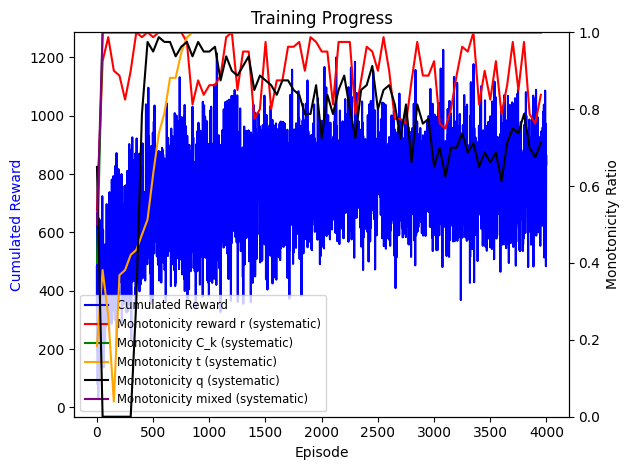

In [16]:
from training.plotting import plot_training_progress, plot_depth_epsilon

plot_training_progress(reward_history, monotonicity_violations)

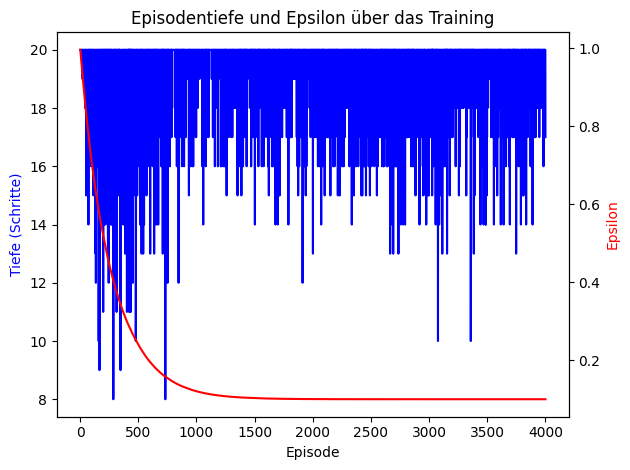

In [17]:
plot_depth_epsilon(depth_history)

## Beispiel-Durchlauf des trainierten Agenten

In [18]:
agent.epsilon = 0.0  # rein exploitativ, keine Exploration

obs, info = env.reset(show_instance = True)
done = False
total_reward = 0.0

while not done:
    action = agent.select_action(obs)
    print(f"Aktion gewählt: {action}")
    obs, reward, terminated, truncated, info = env.step(action)
    env.render()
    total_reward += reward
    done = terminated or truncated

print(f"\nGesamtreward (greedy Durchlauf): {total_reward:.2f}")

Geladene Instanz:
  Anfrage 1: [84, 1, 1, 0, 0]
  Anfrage 2: [8, 1, 1, 0, 0]
  Anfrage 3: [69, 1, 3, 0, 0]
  Anfrage 4: [79, 1, 2, 0, 0]
  Anfrage 5: [84, 1, 1, 0, 0]
  Anfrage 6: [74, 1, 2, 0, 0]
  Anfrage 7: [20, 1, 1, 0, 0]
  Anfrage 8: [34, 2, 1, 0, 0]
  Anfrage 9: [62, 1, 1, 0, 0]
  Anfrage 10: [54, 3, 2, 0, 0]
  Anfrage 11: [54, 3, 2, 0, 0]
  Anfrage 12: [80, 1, 1, 0, 0]
  Anfrage 13: [39, 1, 3, 0, 0]
  Anfrage 14: [63, 3, 2, 0, 0]
  Anfrage 15: [9, 1, 2, 0, 0]
  Anfrage 16: [8, 1, 1, 0, 0]
  Anfrage 17: [21, 2, 1, 0, 0]
  Anfrage 18: [54, 1, 1, 0, 0]
  Anfrage 19: [88, 2, 1, 0, 0]
  Anfrage 20: [25, 1, 1, 0, 0]
Aktion gewählt: 1
t=2    Caps=[9, 9, 10, 10]  r=8.00  q=[1, 1, 0, 0]  Valid Actions: [0, 1, 2, 3]
Aktion gewählt: 1
t=3    Caps=[8, 8, 10, 10]  r=69.00  q=[1, 3, 0, 0]  Valid Actions: [0, 1, 2, 3]
Aktion gewählt: 1
t=4    Caps=[7, 5, 10, 10]  r=79.00  q=[1, 2, 0, 0]  Valid Actions: [0, 1, 2, 3]
Aktion gewählt: 1
t=5    Caps=[6, 3, 10, 10]  r=84.00  q=[1, 1, 0, 0]  Valid A

## Analyse der Reward-History

Diese Zelle berechnet einfache Kennzahlen (Mean, Std, Median, AUC, Final-Mean) aus der vorhandenen `reward_history`-Liste und zeigt einen Plot mit gleitendem Durchschnitt.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

if 'reward_history' not in globals():
    print("Variable 'reward_history' nicht gefunden. Bitte die Trainingszelle ausführen und erneut ausführen.")
else:
    r = np.array(reward_history)
    n = len(r)
    mean_total = r.mean()
    std_total = r.std(ddof=1) if n>1 else 0.0
    median = np.median(r)
    final_mean = r[-50:].mean() if n>=50 else r.mean()
    auc = np.trapz(r)
    auc_norm = auc / max(1, n)
    max_r = r.max()
    min_r = r.min()

    print(f"Episoden: {n}")
    print(f"Mean: {mean_total:.4f}, Std: {std_total:.4f}, Median: {median:.4f}")
    print(f"Final mean (letzte 50): {final_mean:.4f}")
    print(f"AUC (cum. area): {auc:.4f}, AUC_norm: {auc_norm:.4f}")
    print(f"Max: {max_r:.4f}, Min: {min_r:.4f}")

    window = min(50, n)
    if n >= 2:
        mov = np.convolve(r, np.ones(window)/window, mode='valid')
        plt.figure(figsize=(9,4))
        plt.plot(r, label='Cumulated Reward per Episode', alpha=0.6)
        plt.plot(np.arange(window-1, n), mov, label=f'{window}-Episode moving average', color='red')
        plt.xlabel('Episode')
        plt.ylabel('Cumulated Reward')
        plt.title('Reward History und gleitender Durchschnitt')
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        print('Nicht genügend Daten zum Plotten.')